In [1]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
# Load the correct data file and use available columns
df = pd.read_csv(r"../synthetic_online_retail_data.csv")

# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df = df.dropna(subset=['order_date'])

# Calculate price per item (since there is no 'Sale Price' or 'Bottle Volume (ml)')
df['price_per_item'] = df['price'] / df['quantity']

# Extract month and day of week from order_date
df['Month'] = df['order_date'].dt.month_name()
df['Day_of_week'] = df['order_date'].dt.day_name()

Text(0, 0.5, 'Price (USD)')

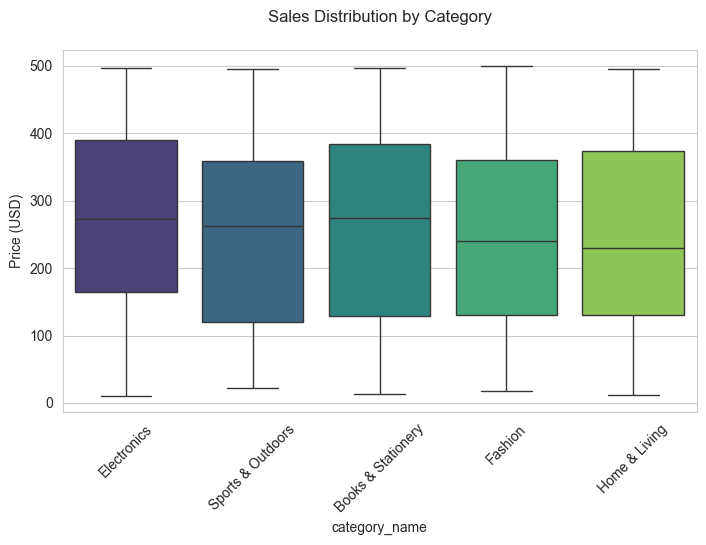

In [3]:
sns.set_style("whitegrid")
plt.figure(figsize=(18, 16))

plt.subplot(3, 2, 1)
ax = sns.boxplot(x='category_name', y='price', data=df, 
                hue='category_name', palette="viridis")
plt.title('Sales Distribution by Category', pad=20)
plt.xticks(rotation=45)
plt.ylabel("Price (USD)")

In [6]:
sns.set_style("whitegrid")
plt.figure(figsize=(7, 4))

# Median price by category
medians = df.groupby('category_name')['price'].median()
for i, cat in enumerate(medians.index):
    plt.text(i, medians[cat], f'{medians[cat]:.0f}', 
             ha='center', va='center', fontweight='bold', color='white')

plt.subplot(1, 2, 1)
# Top 10 cities by total sales
city_sales = df.groupby('city')['price'].sum().nlargest(10)
sns.barplot(x=city_sales.values, y=city_sales.index, palette="rocket")
plt.title('Top 10 Cities by Total Sales', pad=20)
plt.xlabel("Total Sales (USD)")

C:\Users\Manusha\AppData\Local\Temp\ipykernel_8416\3524476400.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_sales.values, y=city_sales.index, palette="rocket")


Text(0.5, 0, 'Total Sales (USD)')

Text(0.5, 0, 'Price (USD)')

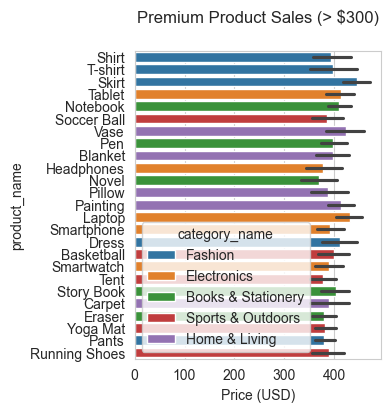

In [10]:
sns.set_style("whitegrid")
plt.figure(figsize=(7, 4))
plt.subplot(1, 2, 2)
# Premium products: price > $300
premium = df[df['price'] > 300][['product_name', 'category_name', 'price']]
premium = premium.sort_values('price', ascending=False)
sns.barplot(x='price', y='product_name', 
            hue='category_name', data=premium, dodge=False)
plt.title('Premium Product Sales (> $300)', pad=20)
plt.xlabel("Price (USD)")

C:\Users\Manusha\AppData\Local\Temp\ipykernel_8416\467082601.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='category_name', y='price_per_item', data=df, palette="Set2", cut=0)


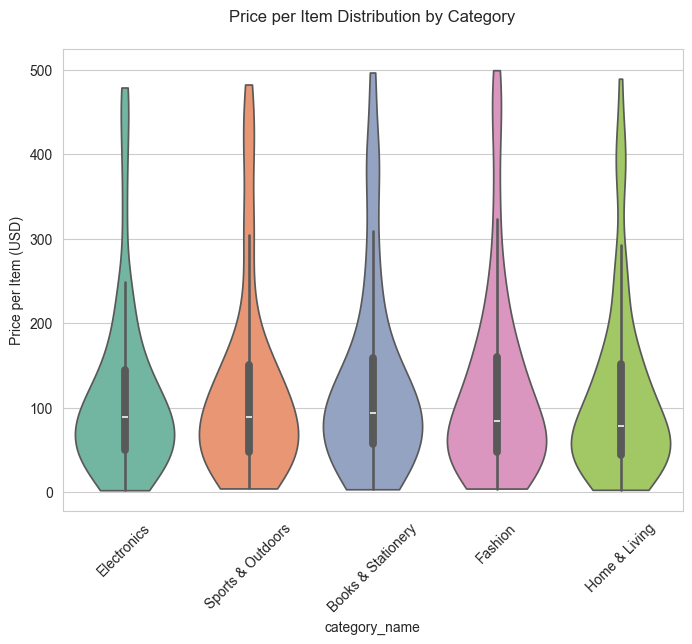

In [12]:
# Violin plot for price per item by category (fixing missing columns)
sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))
if 'category_name' in df.columns and 'price_per_item' in df.columns:
    sns.violinplot(x='category_name', y='price_per_item', data=df, palette="Set2", cut=0)
    plt.title('Price per Item Distribution by Category', pad=20)
    plt.xticks(rotation=45)
    plt.ylabel("Price per Item (USD)")
else:
    print("Required columns 'category_name' and/or 'price_per_item' not found in the dataframe.")

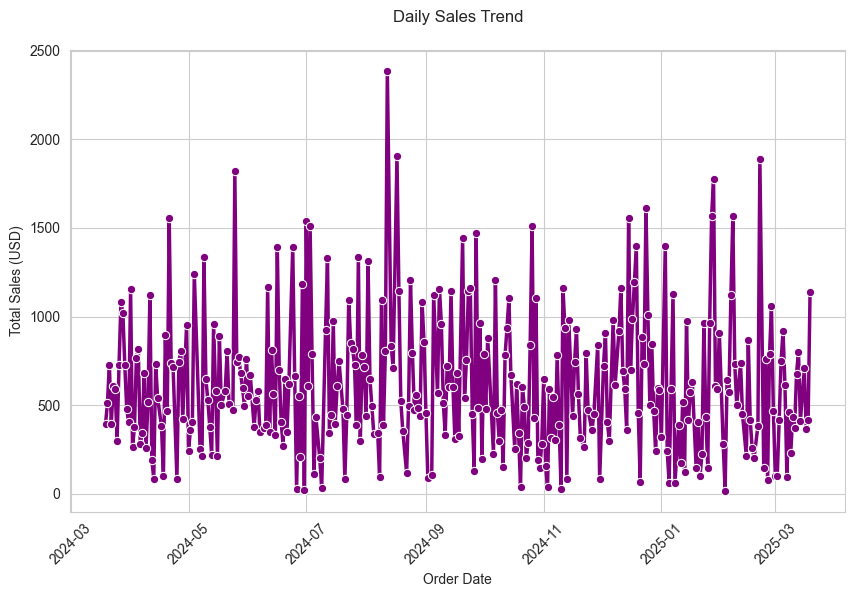

In [14]:
# Daily sales trend plot using available columns
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
if 'order_date' in df.columns and 'price' in df.columns:
    daily_sales = df.groupby('order_date')['price'].sum().reset_index()
    sns.lineplot(x='order_date', y='price', data=daily_sales, marker='o', color='purple', linewidth=2.5)
    plt.title('Daily Sales Trend', pad=20)
    plt.xlabel('Order Date')
    plt.ylabel('Total Sales (USD)')
    plt.xticks(rotation=45)
else:
    print("Required columns 'order_date' and/or 'price' not found in the dataframe.")

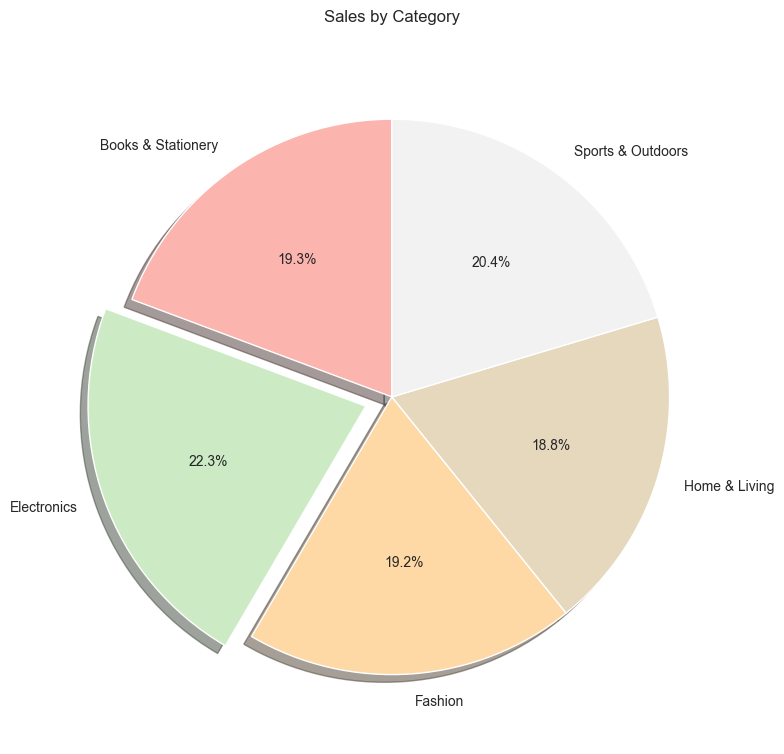

In [16]:
# Pie chart for sales by category (since 'Store Type' and 'Total Sales in USD' do not exist)
sns.set_style("whitegrid")
plt.figure(figsize=(8, 8))
if 'category_name' in df.columns and 'price' in df.columns:
    category_sales = df.groupby('category_name')['price'].sum()
    explode = [0.1 if i == category_sales.idxmax() else 0 for i in category_sales.index]
    category_sales.plot(kind='pie', autopct='%1.1f%%', explode=explode,
                       shadow=True, startangle=90, cmap='Pastel1')
    plt.title('Sales by Category', pad=20)
    plt.ylabel("")
    plt.tight_layout()
    plt.show()
else:
    print("Required columns 'category_name' and/or 'price' not found in the dataframe.")

In [18]:
print("\n=== Key Business Insights ===")
if 'price' in df.columns:
    print(f"1. Total Revenue: ${df['price'].sum():,.2f}")
    print(f"2. Highest Single Transaction: ${df['price'].max():,.2f} ({df.loc[df['price'].idxmax(), 'product_name']} in {df.loc[df['price'].idxmax(), 'city']})")
    if 'quantity' in df.columns and 'product_name' in df.columns:
        most_popular = df.groupby('product_name')['quantity'].sum().idxmax()
        print(f"3. Most Popular Product by Volume: {most_popular}")
    if 'category_name' in df.columns:
        best_category = df.groupby('category_name')['price'].sum().idxmax()
        print(f"4. Best Performing Category: {best_category}")
    premium_revenue = df[df['price'] > 300]['price'].sum()
    percent_premium = premium_revenue / df['price'].sum() * 100 if df['price'].sum() > 0 else 0
    print(f"5. Premium Products (% of revenue): {percent_premium:.1f}%")
else:
    print("Required column 'price' not found in the dataframe.")


=== Key Business Insights ===
1. Total Revenue: $204,573.29
2. Highest Single Transaction: $499.23 (Shirt in Johnstad)
3. Most Popular Product by Volume: Smartphone
4. Best Performing Category: Electronics
5. Premium Products (% of revenue): 64.2%


In [10]:
def show_data_visualisation():
    st.header("📊 Data Visualization")
    
    # Sidebar filters
    with st.sidebar:
        st.header("Filter Data")
        year = st.selectbox("Year", options=sorted(df['Year'].unique()), index=0)
        category = st.multiselect("Category", options=sorted(df['category_name'].unique()), default=list(df['category_name'].unique()))
        city = st.multiselect("City", options=sorted(df['city'].unique()), default=list(df['city'].unique()))
    
    # Filter data
    filtered = df[(df['Year'] == year) & (df['category_name'].isin(category)) & (df['city'].isin(city))]

    # Fix gender_counts
    gender_counts = filtered['gender'].dropna().value_counts().reset_index()
    gender_counts.columns = ['gender_label', 'count']  # safe column names
    fig3 = px.pie(gender_counts, names='gender_label', values='count', title='Gender Distribution')
    st.plotly_chart(fig3, use_container_width=True)


In [16]:
pip install nbformat


  Using cached jsonschema-4.25.0-py3-none-any.whl.metadata (7.7 kB)
  Using cached attrs-25.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached jsonschema_specifications-2025.4.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.36.2-py3-none-any.whl.metadata (2.8 kB)
  Using cached typing_extensions-4.14.1-py3-none-any.whl.metadata (3.0 kB)
Using cached jsonschema-4.25.0-py3-none-any.whl (89 kB)
Using cached attrs-25.3.0-py3-none-any.whl (63 kB)
Using cached jsonschema_specifications-2025.4.1-py3-none-any.whl (18 kB)
Using cached referencing-0.36.2-py3-none-any.whl (26 kB)
Using cached typing_extensions-4.14.1-py3-none-any.whl (43 kB)
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
!pip install nbformat


'pip' is not recognized as an internal or external command,
operable program or batch file.


In [36]:
# Install required packages for static Plotly image export (run this cell if needed)
!pip install kaleido pillow

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
# Gender pie chart with optional year filtering and robust handling for missing/empty gender data and missing nbformat in Jupyter
import plotly.express as px
try:
    import streamlit as st
    # Optional filtering by latest year if 'Year' exists
    if 'Year' in df.columns:
        latest_year = df['Year'].max()
        filtered = df[df['Year'] == latest_year]
    else:
        filtered = df.copy()
    # Check for gender data
    if 'gender' in filtered.columns and not filtered['gender'].dropna().empty:
        gender_counts = filtered['gender'].dropna().value_counts().reset_index()
        gender_counts.columns = ['gender_label', 'count']
        fig = px.pie(gender_counts, names='gender_label', values='count', title='Gender Distribution')
        st.plotly_chart(fig, use_container_width=True)
    else:
        st.info("No gender data available to display.")
except ModuleNotFoundError:
    # Fallback for Jupyter
    import importlib.util
    import sys
    def is_nbformat_installed():
        return importlib.util.find_spec('nbformat') is not None
    if 'Year' in df.columns:
        latest_year = df['Year'].max()
        filtered = df[df['Year'] == latest_year]
    else:
        filtered = df.copy()
    if 'gender' in filtered.columns and not filtered['gender'].dropna().empty:
        gender_counts = filtered['gender'].dropna().value_counts().reset_index()
        gender_counts.columns = ['gender_label', 'count']
        fig = px.pie(gender_counts, names='gender_label', values='count', title='Gender Distribution')
        if is_nbformat_installed():
            try:
                fig.show()
                print("Streamlit is not installed. Showing chart in Jupyter instead.")
            except Exception as e:
                print("Plotly chart could not be displayed:", e)
        else:
            print("Cannot display Plotly chart: nbformat is not installed. Installing now...")
            import subprocess
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'nbformat'])
            print("nbformat installed. Please re-run this cell to display the chart.")
    else:
        print("No gender data available to display.")

Plotly chart could not be displayed: Mime type rendering requires nbformat>=4.2.0 but it is not installed
